# Imports and Data Loading

In [1]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
from geodatasets import get_path
import matplotlib.pyplot as plt
import reverse_geocoder as rg
from xgboost import XGBRegressor
from scipy.stats import spearmanr, pearsonr
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold, PredefinedSplit, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

/Users/isabellawrobleski/Desktop/data-science/ml4cc/mlcc-final-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load data
path = "../data/sat_nutrients_weather_5-3.csv"
df = pd.read_csv(path)

In [3]:
mask = (df["TN_mgL"].notna() | df["TP_mgL"].notna())
df[mask]

,NIR,SWIR,blue,cloud_cover,cyanobacteria_abundance,green,latitude,longitude,ndci,ndti,...,log_abundance,days_difference,is_s2,nutrients_date,TN_mgL,TP_mgL,days_diff_caml_to_nutrients,precip_3d_mm,wind_speed_ms,solar_rad_wm2
0,0.185825,0.119908,0.027397,0.140000,3847.500000,0.05652,34.406896,-119.517000,NaN,0.011317,...,3.585291,3,0,2013-12-17,20.6000,0.048500,0.0,0.00,0.77,2.7041
1,0.061600,0.035000,0.057000,0.131706,9.943000,0.07440,40.702492,-85.935577,-0.202797,0.105498,...,1.039136,2,1,2020-06-09,3.6400,0.180000,0.0,3.78,5.45,5.9666
2,0.066700,0.176800,0.035500,5.508280,5347.500000,0.04720,36.559701,-121.510004,0.184120,-0.116105,...,3.728232,4,1,2018-03-02,51.2000,2.450000,0.0,40.19,2.76,3.2110
3,0.447200,0.408300,0.424300,34.860665,1530.319946,0.42010,38.152599,-121.501001,0.008997,-0.011180,...,3.185066,2,1,2019-01-08,0.5400,NaN,0.0,36.70,3.11,0.7898
4,0.020600,0.014500,0.018500,30.228207,46.060001,0.02420,41.330565,-85.383607,0.052369,0.120370,...,1.672652,5,1,2021-08-30,NaN,0.100000,0.0,7.70,1.73,5.5553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5366,0.038700,0.038600,0.040400,46.371841,7.567000,0.04060,36.400003,-76.929999,0.137300,0.037037,...,0.932829,5,1,2021-06-15,0.1350,0.060000,14.0,10.05,1.61,6.8587
5367,0.252800,0.322500,0.084700,0.006369,5727.500000,0.12510,37.320402,-120.983001,0.461190,-0.124563,...,3.758041,2,1,2019-04-30,0.2000,NaN,14.0,0.00,2.74,6.8585
5368,0.076200,0.055100,0.043000,11.966699,338.625000,0.06380,39.399199,-99.424813,0.224054,0.229287,...,2.531000,2,1,2018-08-13,0.0001,0.000092,14.0,37.08,2.62,6.4063
5369,0.117200,0.110200,0.101600,41.783652,5.554000,0.10460,36.049999,-76.679999,0.109881,0.000478,...,0.816506,1,1,2019-05-29,NaN,0.040000,14.0,5.08,1.56,7.8547


# Creating Spatial Groups

In [4]:
# create rounded latitude and longitude cols
df["lon_binned"] = df["longitude"].round(0)
df["lat_binned"] = df["latitude"].round(0)

# create day of year col
df["sample_date"] = pd.to_datetime(df["sample_date"])
df['day_of_yr'] = df['sample_date'].dt.dayofyear

/Users/isabellawrobleski/Desktop/data-science/ml4cc/mlcc-final-project/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


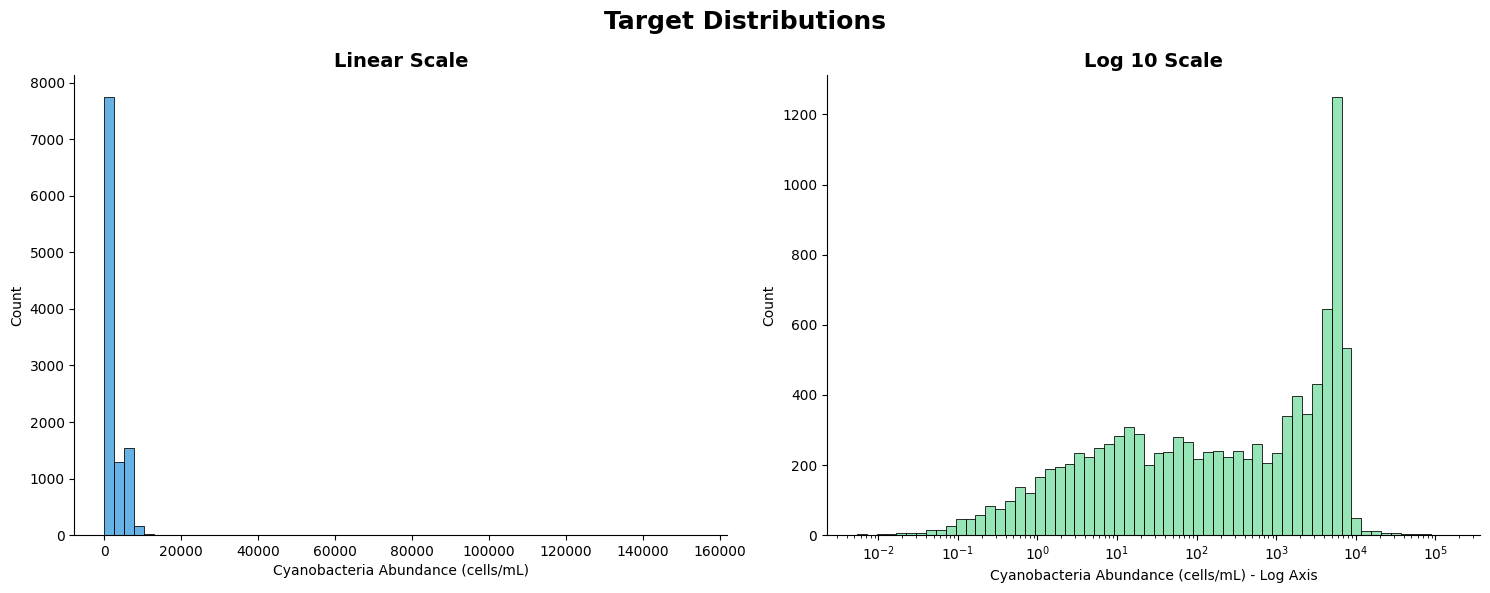

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target Distributions', fontsize=18, fontweight='bold')

# linear scale
sns.histplot(
    data=df, 
    x="cyanobacteria_abundance", 
    ax=axes[0], 
    color="#3498db",
    bins=60
)
axes[0].set_title("Linear Scale", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Cyanobacteria Abundance (cells/mL)")

# log scale
sns.histplot(
    data=df, 
    x="cyanobacteria_abundance", 
    ax=axes[1], 
    color="#2ecc71",
    bins=60, 
    log_scale=True, 
    kde=True
)
axes[1].set_title("Log 10 Scale", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Cyanobacteria Abundance (cells/mL) - Log Axis")

sns.despine()
plt.tight_layout()
plt.show()

# Estimating Model Potential and Tuning Hyperparameters with Spatial Cross-Validation

## Creating and Visualizing Folds

In [6]:
# split data into X and y
drop_cols = ["cyanobacteria_abundance", "log_abundance", "satellite_date", "nutrients_date", "sample_date", "is_s2", "days_difference"]
X = df.drop(columns=drop_cols)
y = df["log_abundance"]

In [7]:
# create spatial groups
groups = (X["lat_binned"].astype(str) + "_" + X["lon_binned"].astype(str))

# bin y to create levels of log abundance values for stratified k folds
y_binned = pd.qcut(y, q=5, labels=False)

# set up splitter, create folds, assign each row to its fold index, create fold column for visualization
sgkf = StratifiedGroupKFold(n_splits=5)
fold_map = np.full(len(X), -1)
X["fold"] = -1
for i, (train_idx, test_idx) in enumerate(sgkf.split(X, y_binned, groups=groups)):
    fold_map[test_idx] = i
    X.loc[test_idx, "fold"] = i

# drop exact latitude and longitude
X_clean = X.drop(columns=["latitude", "longitude", "lat_binned", "lon_binned", "fold"])

# create a predefined split so the same folds are used in every search
ps = PredefinedSplit(test_fold=fold_map)

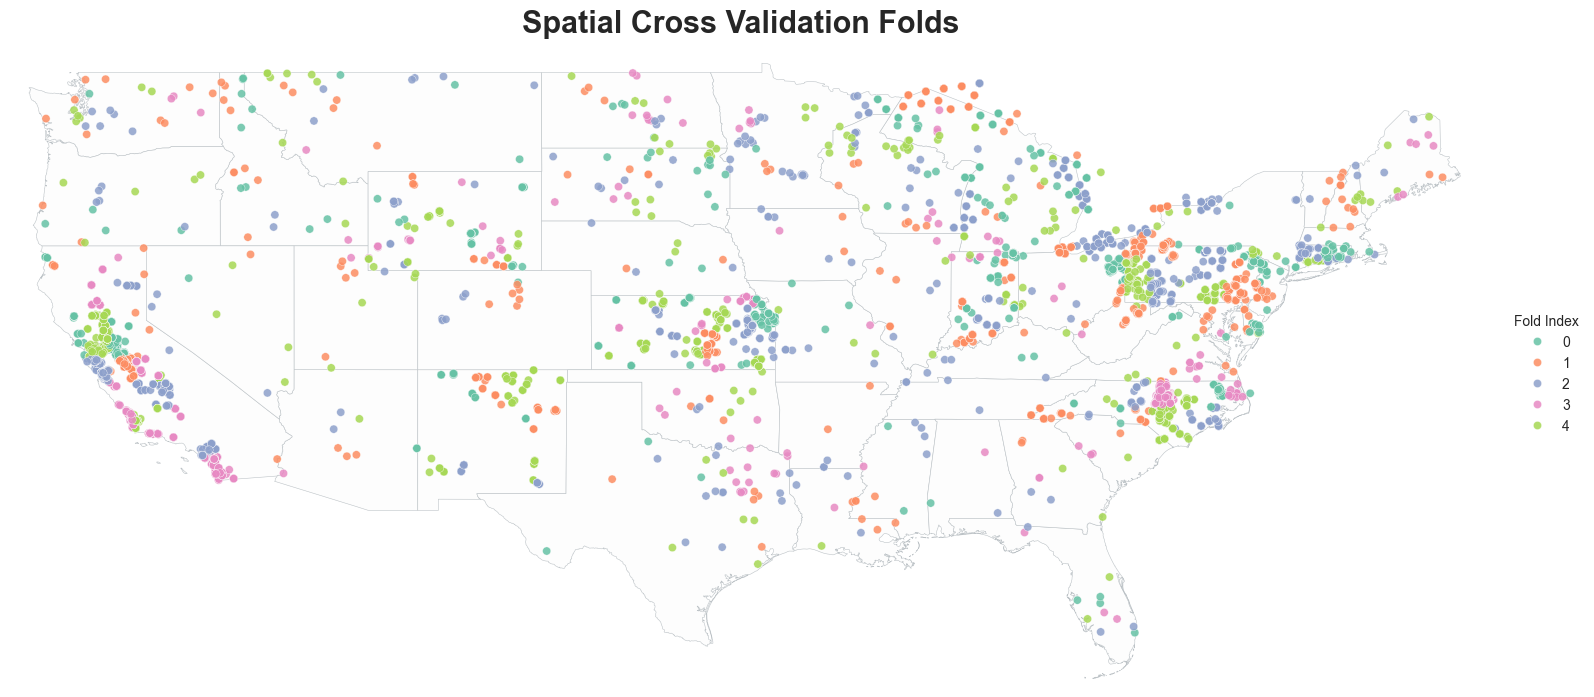

In [8]:
# get highres usa boundaries
high_res_url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces.zip"
states_hr = gpd.read_file(high_res_url)
usa_hr = states_hr[states_hr.iso_a2 == "US"]
contiguous_hr = usa_hr[~usa_hr.name.isin(["Alaska", "Hawaii"])]

# plot boundaries
sns.set_style("white")
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_facecolor('#d4f1f9')
contiguous_hr.plot(ax=ax, color='#fdfdfd', edgecolor='#bdc3c7', linewidth=0.4, zorder=1)

# plot folds
scatter = sns.scatterplot(
    data=X, 
    x="longitude", 
    y="latitude", 
    hue="fold", 
    palette="Set2",     
    s=35,               
    alpha=0.85, 
    edgecolor="white", 
    linewidth=0.3,
    ax=ax,
    zorder=2
)

ax.set_aspect('equal')
ax.set_xlim(-125.5, -66.5)
ax.set_ylim(24.2, 49.5)
ax.axis('off')
plt.title("Spatial Cross Validation Folds", fontsize=22, fontweight='bold', loc='center', pad=20)
plt.legend(title='Fold Index', bbox_to_anchor=(1.02, 0.5), loc="center left", frameon=False)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning and Cross-Validation

In [38]:
param_grids = [
{ # grid for xgb
    'max_depth': [3, 4, 5, 7],         
    'learning_rate': [0.01, 0.05],    
    'subsample': [0.6, 0.7, 0.8],      
    'colsample_bytree': [0.6, 0.7],    
    'n_estimators': [500, 1000],
    'reg_lambda': [1, 5, 10],          
    'reg_alpha': [0, 1, 5],            
    'gamma': [0, 0.1, 0.2, 0.5],       
    'min_child_weight': [1, 5, 10]
},
{ # grid for rf
    'n_estimators': [500],                 
    'max_depth': [4, 6, 8, 10],             
    'min_samples_split': [10, 20],          
    'min_samples_leaf': [5, 10, 20],        
    'max_features': ['sqrt'],              
    'max_samples': [0.6, 0.7, 0.8],         
    'ccp_alpha': [0.0, 0.01, 0.1]           
},
{ # grid for hgb
    'max_iter': [500, 1000],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05],
    'l2_regularization': [1, 10, 100],
    'min_samples_leaf': [20, 50, 100],
    'max_leaf_nodes': [15, 31],         
    'max_features': [0.7, 0.8]          
}]

models = [XGBRegressor, RandomForestRegressor, HistGradientBoostingRegressor]
names = ["xgb", "rf", "hgb"]
results = {"xgb": {}, "rf": {}, "hgb": {}}

In [39]:
for model, name, param_grid in zip(models, names, param_grids):
    print(f'--------{name.upper()}--------')

    search = RandomizedSearchCV(
        estimator=model(random_state=42),
        param_distributions=param_grid,
        n_iter=100, 
        cv=ps,
        scoring='r2',
        verbose=1,
        n_jobs=-1
    )

    search.fit(X_clean, y)
    
    results[name]["params"] = search.best_params_
    results[name]["model"] = search.best_estimator_
    results[name]["best_score"] = search.best_score_

    results_df = pd.DataFrame(search.cv_results_)
    model = search.best_estimator_

    rmse = []
    medae = []
    all_preds = []
    all_actual = []

    for train_idx, test_idx in ps.split():
        X_test, y_test = X_clean.iloc[test_idx], y.iloc[test_idx]
        preds = model.predict(X_test)
        preds_transformed = (10 ** preds) - 1

        all_preds.extend(preds)
        all_actual.extend(y_test)

        rmse.append(np.sqrt(mean_squared_error(y_test, preds)))
        medae.append(np.median(np.abs(y_test - preds_transformed)))
    
    results[name]["rmse"] = np.mean(np.array(rmse))
    results[name]["medae"] = np.median(np.array(medae))

    print(f'Best Score: {results[name]["best_score"]}')
    print(f'Average RMSE: {results[name]["rmse"]}')
    print(f'Median MedAE: {results[name]["medae"]}')


--------XGB--------
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Score: 0.5807190605529089
Average RMSE: 0.4926695870803588
Median MedAE: 244.5668324129526
--------RF--------
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Score: 0.5476336616528161
Average RMSE: 0.6587478455280353
Median MedAE: 170.59183030379378
--------HGB--------
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Score: 0.5800962948917451
Average RMSE: 0.5636419365092453
Median MedAE: 234.9788087247602


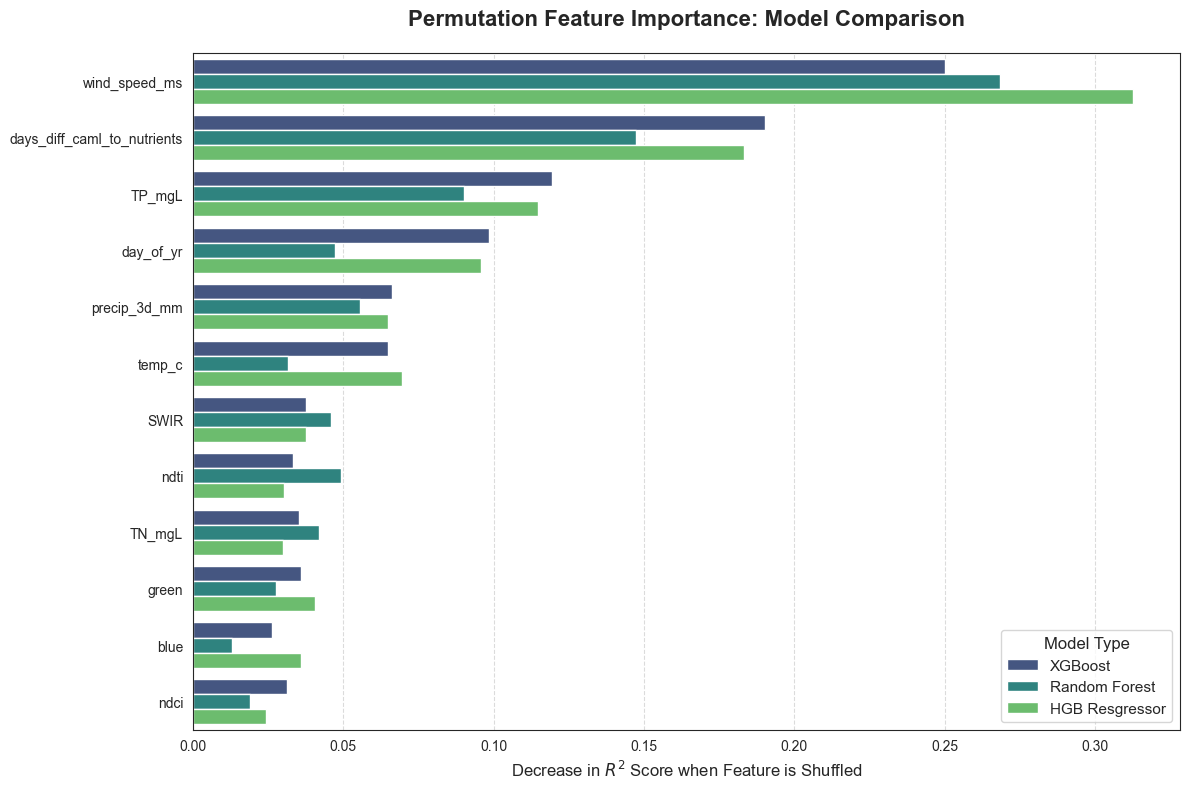

In [40]:
models = {
    'XGBoost': results["xgb"]["model"],
    'Random Forest': results["rf"]["model"],
    'HGB Resgressor': results["hgb"]["model"],
}

all_importances = []

# importance for each model
for name, model in models.items():
    res = permutation_importance(
        model, X_clean, y, 
        n_repeats=10, 
        random_state=42, 
        n_jobs=-1
    )
    
    # store results
    temp_df = pd.DataFrame({
        'feature': X_clean.columns,
        'importance': res.importances_mean,
        'model': name
    })
    all_importances.append(temp_df)

# combine
full_df = pd.concat(all_importances)

# order features by average importance 
top_features = full_df.groupby('feature')['importance'].mean().sort_values(ascending=False).head(12).index
plot_df = full_df[full_df['feature'].isin(top_features)]

# plot
plt.figure(figsize=(12, 8))
sns.barplot(
    data=plot_df,
    x='importance',
    y='feature',
    hue='model',
    palette='viridis',
    order=top_features
)
plt.title('Permutation Feature Importance: Model Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Decrease in $R^2$ Score when Feature is Shuffled', fontsize=12)
plt.ylabel('')
plt.legend(title='Model Type', title_fontsize='12', fontsize='11', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Evaluating Generalization with Out-of-Distribution Test Sets

In [42]:
# adding a state column to remove a state for testing
coords = list(zip(df['latitude'], df['longitude']))
search_res = rg.search(coords)

df['state'] = [res['admin1'] for res in search_res]

In [ ]:
# holdout state sets
holdout_states_pnw = ["Washington", "Oregon", "Idaho", "Montana", "Wyoming"]
holdout_states_mw = ["Ohio", "Indiana", "Michigan", "Pennsylvania"]
holdout_states_ne = ["New York", "Connecticut", "Delaware", "Pennsylvania"]
out_of_dist_res = {"Pacific Northwest": {"xgb": {}, "rf": {}, "hgb": {}}, 
                   "Midwest": {"xgb": {}, "rf": {}, "hgb": {}}, 
                   "Northeast": {"xgb": {}, "rf": {}, "hgb": {}}}

for holdout, holdout_name in zip([holdout_states_pnw, holdout_states_mw, holdout_states_ne], ["Pacific Northwest", "Midwest", "Northeast"]):
    print(f'-------{holdout_name.upper()}-------')

    df_test = df[df['state'].isin(holdout)].copy()
    df_train = df[~df['state'].isin(holdout)].copy()
    print(f'Test Set Size: {df_test.shape[0]}')

    drop_cols = ["cyanobacteria_abundance", "log_abundance", "satellite_date", "nutrients_date", "sample_date", "is_s2", "latitude", "longitude", "lat_binned", "lon_binned", "state"]
    X_test = df_test.drop(columns=drop_cols).reset_index(drop=True)
    X_train = df_train.drop(columns=drop_cols).reset_index(drop=True)
    y_test = df_test["log_abundance"].reset_index(drop=True)
    y_train = df_train["log_abundance"].reset_index(drop=True)

    for name, function, params in zip(["xgb", "rf", "hgb"], 
                                  [XGBRegressor, RandomForestRegressor, HistGradientBoostingRegressor],
                                  [results["xgb"]["params"], results["rf"]["params"], results["hgb"]["params"]]):

        model = function(**params)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        preds_transformed = (10 ** preds) - 1

        out_of_dist_res[holdout_name][name]["r squared"] = model.score(X_test, y_test)
        out_of_dist_res[holdout_name][name]["rmse"] = np.sqrt(mean_squared_error(y_test, preds))
        out_of_dist_res[holdout_name][name]["medae"] = np.median(np.abs(y_test - preds_transformed))
        out_of_dist_res[holdout_name][name]["rho"] = spearmanr(y_test, preds)[0]

        '''plt.figure(figsize=(8, 6))
        plt.scatter(y_test_pnw, preds, alpha=0.5)
        plt.plot([y_test.min(), y_test_pnw.max()], [y_test_pnw.min(), y_test_pnw.max()], 'r--')
        plt.title(f'Pacific Northwest Holdout: Actual vs. Predicted ({name})')
        plt.xlabel('Actual (Log Abundance)')
        plt.ylabel('Predicted (Log Abundance)')
        plt.show()'''

        print(f'{name.upper()}: {out_of_dist_res[holdout_name][name]}')


-------PACIFIC NORTHWEST-------
Test Set Size: 184
XGB: {'r squared': 0.05793352407231056, 'rmse': np.float64(1.0247484039004693), 'medae': np.float64(99.77913078574213), 'rho': np.float64(0.42355955385178473)}
RF: {'r squared': 0.09874413601872878, 'rmse': np.float64(1.0023064556689985), 'medae': np.float64(75.11548040685298), 'rho': np.float64(0.4742809809096338)}
HGB: {'r squared': 0.049000271508862325, 'rmse': np.float64(1.0295955866998556), 'medae': np.float64(98.28164841081748), 'rho': np.float64(0.42953901870509137)}
-------MIDWEST-------
Test Set Size: 1820
XGB: {'r squared': 0.1283867168909666, 'rmse': np.float64(0.9761630084625919), 'medae': np.float64(29.745296153911422), 'rho': np.float64(0.42047307710820325)}
RF: {'r squared': 0.09270159216826279, 'rmse': np.float64(0.9959453320383547), 'medae': np.float64(37.35727710071531), 'rho': np.float64(0.3946086917033872)}
HGB: {'r squared': 0.11563479368598462, 'rmse': np.float64(0.983277836110582), 'medae': np.float64(27.80692106